# Relative Approximation Ratio -- HEA & QAOA (extra ansatze)

Chi tinh 2 ansatz moi (**HEA** L=2, **QAOA** p=2) tren 5 init, CUNG dai qubit / instance /
budget optimizer voi `Ratio_5_Initializations_Exact`, xuat `ratio_5inits_extra.json`.

Cell cuoi merge voi `ratio_5inits_exact.json` (IQP: single/circular/full da chay) de ve
**5 duong/subplot** -- KHONG chay lai IQP.

> Budget = 1000 iters, lr=1e-3 (giong file IQP) de merge cong bang. Luu y: cac init
> variance nho (he/glorot, pi4) co the UNDERTRAINED o n lon -- dung ngan sach nay chi
> de dong bo voi hinh IQP hien tai.

In [1]:
import json
import numpy as np
import pennylane as qp
from pennylane import numpy as qnp
import matplotlib.pyplot as plt

from ansatz_extra import apply_ansatz, n_params_for, init_params
from IQP_circuit_pennylane import binary_ops_to_hamiltonian
from IQP_circuit import maxcut_obs, number_partition_obs
from MaxCut import maxcut_value, solve_maxcut_exact_symmetry
from Partition import sum_selected
from numberpartitioning import karmarkar_karp

## Helpers + optimizer budget (giong file IQP)

In [2]:
N_ITERS  = 1000
STEPSIZE = 1e-3

def ising_obs_local(n_qubits, corr=2):
    obs = []
    for i in range(n_qubits):
        v = [0] * n_qubits; v[i] = 1; obs.append(v)
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                v = [0] * n_qubits; v[i] = 1; v[j] = 1; obs.append(v)
    return np.array(obs)

## Load datasets (cung file voi ban IQP)

In [3]:
with open("ising.json", "r") as f:
    dataset_ising = {int(k): v for k, v in json.load(f).items()}
with open("ising_loss_exact.json", "r") as f:
    exact_ising = {int(k): v for k, v in json.load(f).items()}
with open("maxcut.json", "r") as f:
    dataset_maxcut = {int(k): v for k, v in json.load(f).items()}
with open("partition.json", "r") as f:
    dataset_partition = {int(k): v for k, v in json.load(f).items()}

print("Datasets loaded successfully")

Datasets loaded successfully


## Optimization core (tong quat theo ansatz)
Giong `train_exact` ban IQP nhung goi `apply_ansatz` + luong them `ops, coeffs, ansatz, spec`
(QAOA can `ops, coeffs` de dung lop cost; IQP/HEA bo qua chung).

In [4]:
def _expval_flat_a(params, H, ops, coeffs, n_qubits, ansatz, spec):
    apply_ansatz(params, ops, coeffs, n_qubits, ansatz, spec)
    return qp.expval(H)

def _probs_flat_a(params, ops, coeffs, n_qubits, ansatz, spec):
    apply_ansatz(params, ops, coeffs, n_qubits, ansatz, spec)
    return qp.probs(wires=range(n_qubits))

def train_exact_a(H, ops, coeffs, n_qubits, ansatz, spec, params_init,
                  n_iters=N_ITERS, stepsize=STEPSIZE):
    dev   = qp.device("lightning.qubit", wires=n_qubits, shots=None)
    qnode = qp.QNode(_expval_flat_a, dev, interface="autograd")
    params = qnp.array(params_init, requires_grad=True)
    opt = qp.AdamOptimizer(stepsize)
    cost = lambda p: qnode(p, H, ops, coeffs, n_qubits, ansatz, spec)
    for _ in range(n_iters):
        params = opt.step(cost, params)
    return params, float(cost(params))

def get_probs_a(params, ops, coeffs, n_qubits, ansatz, spec):
    dev   = qp.device("lightning.qubit", wires=n_qubits, shots=None)
    qnode = qp.QNode(_probs_flat_a, dev, interface="autograd")
    return np.array(qnode(qnp.array(params, requires_grad=False),
                          ops, coeffs, n_qubits, ansatz, spec))

## Ratio functions (dinh nghia r_RA y het ban IQP; chi doi mode_circuit -> ansatz, spec)

In [5]:
def ratio_ising(n, j, init, ansatz, spec):
    coeffs = np.array(dataset_ising[n][j])
    ops = ising_obs_local(n, 2)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_params_for(ansatz, spec, n), n)
    _, final_loss = train_exact_a(H, ops, coeffs, n, ansatz, spec, p0)
    return float((exact_ising[n][j] - final_loss) / exact_ising[n][j])

def ratio_maxcut(n, j, init, ansatz, spec):
    edges, weights = dataset_maxcut[n][j]
    ops, coeffs = maxcut_obs(n, edges, weights)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_params_for(ansatz, spec, n), n)
    params, _ = train_exact_a(H, ops, coeffs, n, ansatz, spec, p0)
    probs = get_probs_a(params, ops, coeffs, n, ansatz, spec)
    bits = np.binary_repr(int(np.argmax(probs)), n)
    sol = maxcut_value(bits, edges, weights)
    ex = solve_maxcut_exact_symmetry(edges, weights)[0]
    return float(abs(sol - ex) / ex)

def ratio_partition(n, j, init, ansatz, spec):
    numbers = dataset_partition[n][j]
    ops, coeffs = number_partition_obs(numbers)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_params_for(ansatz, spec, n), n)
    params, _ = train_exact_a(H, ops, coeffs, n, ansatz, spec, p0)
    probs = get_probs_a(params, ops, coeffs, n, ansatz, spec)
    bits = np.binary_repr(int(np.argmax(probs)), n)
    sol = sum_selected(bits, numbers)
    ex = karmarkar_karp(numbers, num_parts=2)
    denom = sum(ex.partition[0])
    return float(abs(sol - denom) / denom)

ratio_fns = {'ising': ratio_ising, 'maxcut': ratio_maxcut, 'partition': ratio_partition}

## Tinh ratio cho HEA & QAOA
CUNG `qubits`, `inits`, `n_problem` voi file IQP de merge khop. Key tang circuit = `'hea'`/`'qaoa'`.

> **Chi phi lon** (50 instances x 5 init x 2 ansatz x 3 ham x 5 n). Thu nho truoc:
> `qubits=[3,6]`, `n_problem=5`, roi moi chay full.

In [ ]:
np.random.seed(42)

inits             = ['normal', 'uniform', 'pi4', 'he', 'glorot']
mode_hamiltonians = ['ising', 'maxcut', 'partition']
ansatz_configs    = [('hea', 2), ('qaoa', 2)]   # label tang circuit = ten ansatz
qubits            = [3, 6, 9, 12, 15]
n_problem         = 50

all_extra = {}
for init_name in inits:
    print(f"\n{'='*40}\nInit: {init_name}")
    results = {}
    for mode_ham in mode_hamiltonians:
        print(f"  === {mode_ham} ===")
        results[mode_ham] = {}
        rfn = ratio_fns[mode_ham]
        for ansatz, spec in ansatz_configs:
            key = ansatz  # 'hea' / 'qaoa'
            print(f"    {key}")
            results[mode_ham][key] = {}
            for n_qubits in qubits:
                print(f"      n={n_qubits}", end=" ... ", flush=True)
                ratios = [rfn(n_qubits, j, init_name, ansatz, spec)
                          for j in range(n_problem)]
                results[mode_ham][key][n_qubits] = ratios
                print(f"mean={np.mean(ratios):.3f}")
    all_extra[init_name] = results

with open("ratio_5inits_extra.json", "w") as f:
    json.dump(all_extra, f, indent=4)
print("\nSaved to ratio_5inits_extra.json")


Init: normal
  === ising ===
    hea
      n=3 ... mean=0.307
      n=6 ... mean=0.392
      n=9 ... mean=0.471
      n=12 ... mean=0.458
      n=15 ... mean=0.506
    qaoa
      n=3 ... mean=0.402
      n=6 ... mean=0.618
      n=9 ... mean=0.725
      n=12 ... mean=0.800
      n=15 ... mean=0.750
  === maxcut ===
    hea
      n=3 ... mean=0.041
      n=6 ... mean=0.074
      n=9 ... mean=0.102
      n=12 ... mean=0.100
      n=15 ... mean=0.111
    qaoa
      n=3 ... mean=0.012
      n=6 ... mean=0.095
      n=9 ... mean=0.122
      n=12 ... mean=0.179
      n=15 ... mean=0.157
  === partition ===
    hea
      n=3 ... mean=0.089
      n=6 ... mean=0.093
      n=9 ... mean=0.105
      n=12 ... mean=0.081
      n=15 ... mean=0.068
    qaoa
      n=3 ... mean=0.196
      n=6 ... mean=0.367
      n=9 ... mean=0.246
      n=12 ... mean=0.203
      n=15 ... mean=0.276

Init: uniform
  === ising ===
    hea
      n=3 ... mean=0.270
      n=6 ... mean=0.354
      n=9 ... mean=0.412
      

## Merge voi IQP + ve 5 ansatz
r_RA la dai luong TUYET DOI (khong chuan hoa). Ghep hea/qaoa vao tang circuit roi ve 3x5.
Dung `sharey='row'` de moi hang tu chinh scale bao gom ca HEA/QAOA (thay vi ylim cung cua hinh IQP).

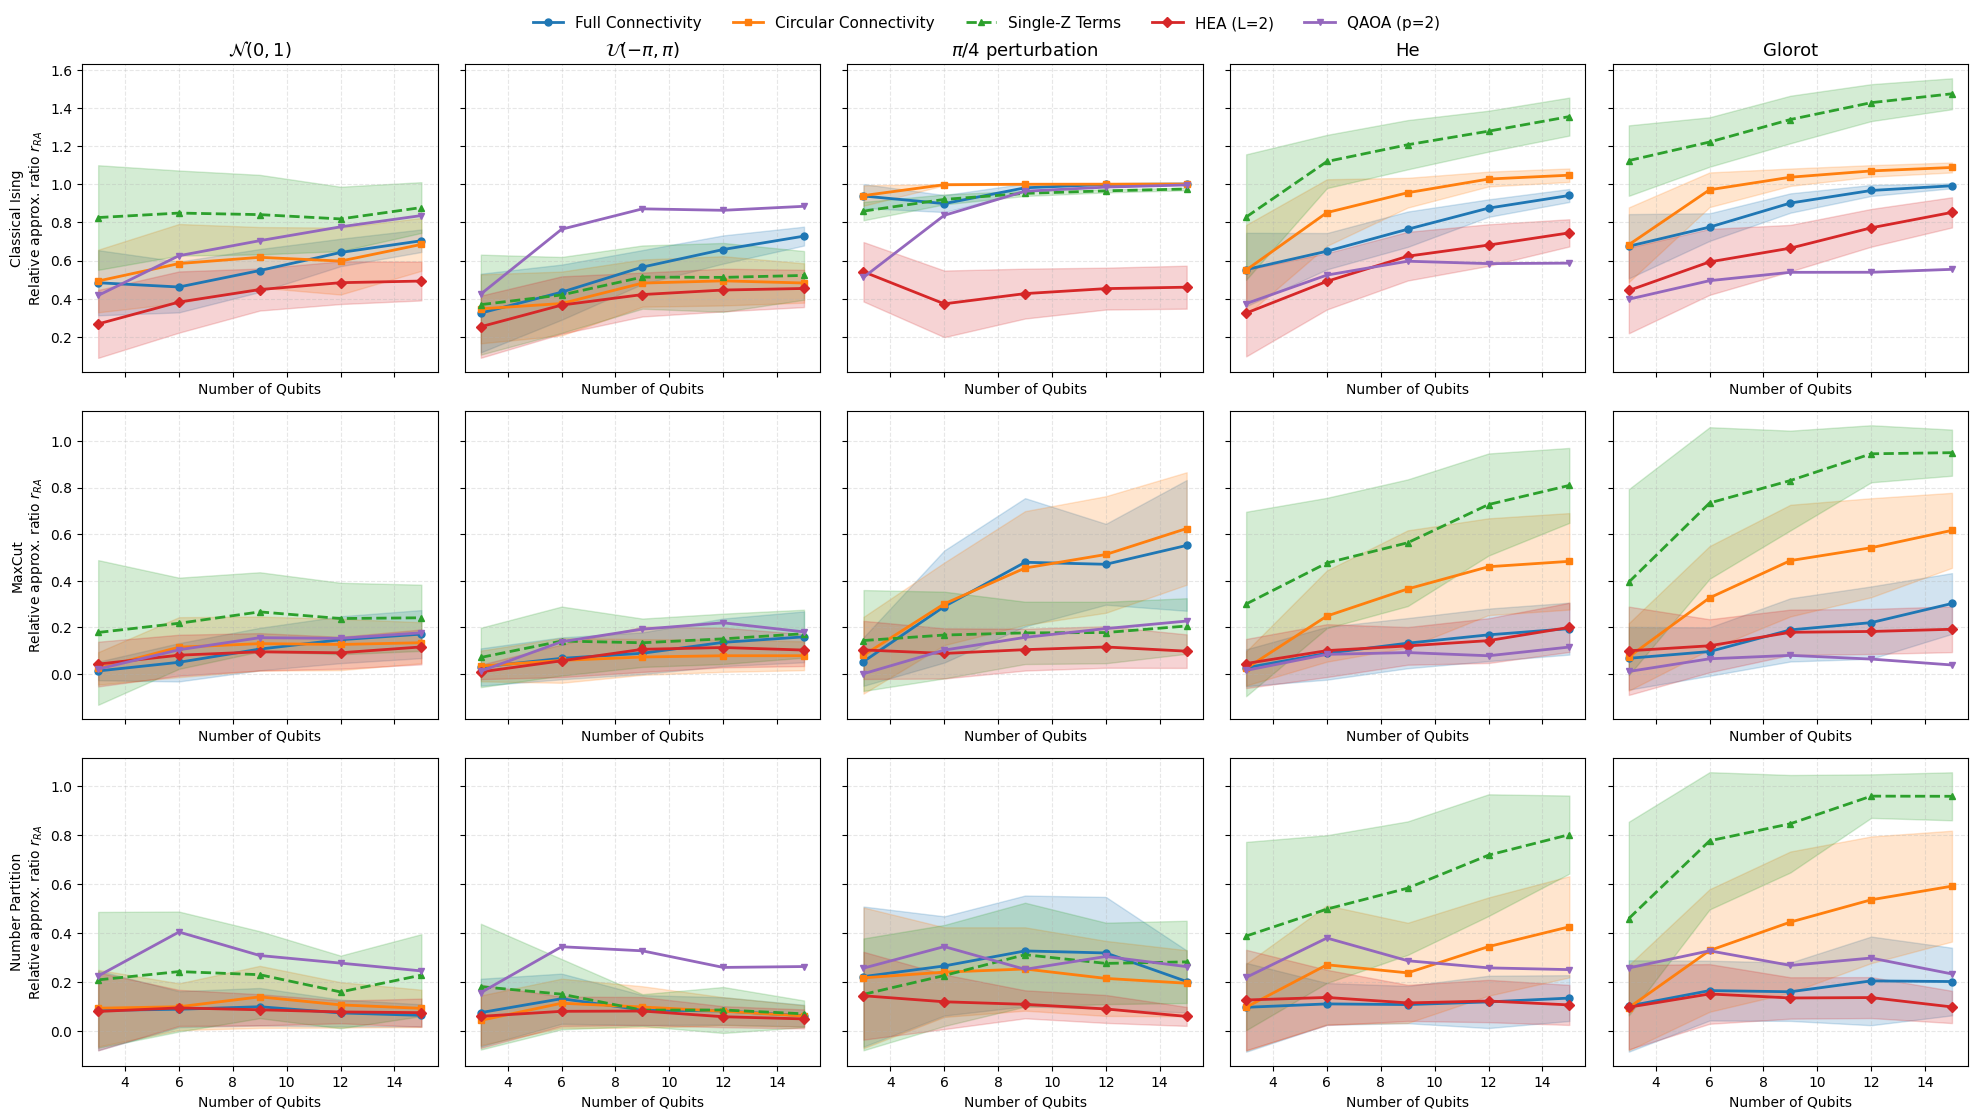

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open("ratio_5inits_exact.json", "r") as f:
    base = json.load(f)        # IQP: single / circular / full
with open("ratio_5inits_extra_parallel.json", "r") as f:
    extra = json.load(f)       # hea / qaoa

# merge: them hea/qaoa vao tang circuit cua tung (init, ham)
merged = {}
for init_name in base:
    merged[init_name] = {}
    for ham in base[init_name]:
        merged[init_name][ham] = dict(base[init_name][ham])
        merged[init_name][ham].update(extra[init_name][ham])

qubits = [3, 6, 9, 12, 15]
ham_names = {'ising': 'Classical Ising', 'maxcut': 'MaxCut', 'partition': 'Number Partition'}
order  = ['full', 'circular', 'single', 'hea', 'qaoa']
styles = {'full': ('o-', '#1f77b4'), 'circular': ('s-', '#ff7f0e'), 'single': ('^--', '#2ca02c'),
          'hea': ('D-', '#d62728'), 'qaoa': ('v-', '#9467bd')}
labels = {'full': 'Full Connectivity', 'circular': 'Circular Connectivity',
          'single': 'Single-Z Terms', 'hea': 'HEA (L=2)', 'qaoa': 'QAOA (p=2)'}
init_cols  = ['normal', 'uniform', 'pi4', 'he', 'glorot']
col_titles = {'normal': r'$\mathcal{N}(0, 1)$', 'uniform': r'$\mathcal{U}(-\pi, \pi)$',
              'pi4': r'$\pi/4$ perturbation', 'he': 'He', 'glorot': 'Glorot'}

fig, axes = plt.subplots(3, 5, figsize=(20, 11), sharex=True, sharey='row')
for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax  = axes[row][col]
        res = merged[init_name][mode_ham]
        for mc in order:
            means = np.array([np.mean(res[mc][str(n)]) for n in qubits])
            stds  = np.array([np.std(res[mc][str(n)])  for n in qubits])
            fmt, color = styles[mc]
            ax.plot(qubits, means, fmt, color=color, label=labels[mc], linewidth=2, markersize=5)
            if mc != 'qaoa':
                ax.fill_between(qubits, means - stds, means + stds, color=color, alpha=0.2)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(f'{ham_names[mode_ham]}\n' r'Relative approx. ratio $r_{RA}$', fontsize=10)
        if row == 0:
            ax.set_title(col_titles[init_name], fontsize=13)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig("Ratio_5_initializations_5ansatz.pdf", dpi=300, bbox_inches='tight')
plt.show()